<a href="https://colab.research.google.com/github/laryferreira/ieeecisIA/blob/studies/WineQuality_LaryssaFerreira_IEEE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Desafio WineQuality - IEEE Computer Society
*   Laryssa de Oliveira Ferreira
*   222005386





## Descrição do desafio:

O Vinho verde é um produto único da região de Minho, do Noroeste de
Portugal. Médio em álcool, este vinho é particularmente apreciado devido ao seu
frescor, especialmente no verão. Com base nisso, foram coletadas as seguintes
informações sobre o vinho:

1 - acidez fixa (fixed acidity)

2 - acidez volátil (volatile acidity)

3 - acidez cítrica (citric acidity)


4 - açúcar residual (residual sugar)

5 - concentração de cloretos (chlorides)

6 - concentração de dióxido sulfúrico livre(free sulfur dioxide)

7 - concentração total de dióxido sulfúrico (total sulfur dioxide)

8 - densidade (density)

9 - pH (pH)

10 - concentração de sulfatos (sulphates)

11 - concentração alcoólica (alcohol)

Output (based na avaliação média de especialistas):

12 - qualidade (quality) (score entre 0 e 10)

Há dois datasets, relacionados às variantes vermelha e branca do “vinho
verde”
, de Portugal.

Escolha um dos datasets contendo informações de uma das
variantes (vermelha ou branca) e crie um modelo de regressão para prever a
qualidade do vinho.

A entrega é individual e deverá ser colocada no seu GitHub
pessoal.

**Atenção, a LLM Gemini Pro foi utilizada para me auxiliar na plotagem dos gráficos, ainda estou aprendendo!**

1.1 Importação das bibliotecas essenciais


In [16]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

1.2 Limpeza e checagem do dataset


In [17]:
file_path = 'winequality-white.csv'
try:
    df_white = pd.read_csv(file_path, sep=';')
    print(f"Dataset '{file_path}' carregado com sucesso.")

    print("\nPrimeiras 5 linhas do dataset:")
    print(df_white.head())

    print("\nColunas do dataset:")
    print(df_white.columns)

except FileNotFoundError:
    print(f"\nERRO: O arquivo '{file_path}' não foi encontrado.")

Dataset 'winequality-white.csv' carregado com sucesso.

Primeiras 5 linhas do dataset:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.0              0.27         0.36            20.7      0.045   
1            6.3              0.30         0.34             1.6      0.049   
2            8.1              0.28         0.40             6.9      0.050   
3            7.2              0.23         0.32             8.5      0.058   
4            7.2              0.23         0.32             8.5      0.058   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 45.0                 170.0   1.0010  3.00       0.45   
1                 14.0                 132.0   0.9940  3.30       0.49   
2                 30.0                  97.0   0.9951  3.26       0.44   
3                 47.0                 186.0   0.9956  3.19       0.40   
4                 47.0                 186.0   0.9956  3.19       0.40   


2.1 Distribuição da qualidade para entender o contexto do dataset


<ipython-input-18-2156936289>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_white, x='quality', palette='viridis')


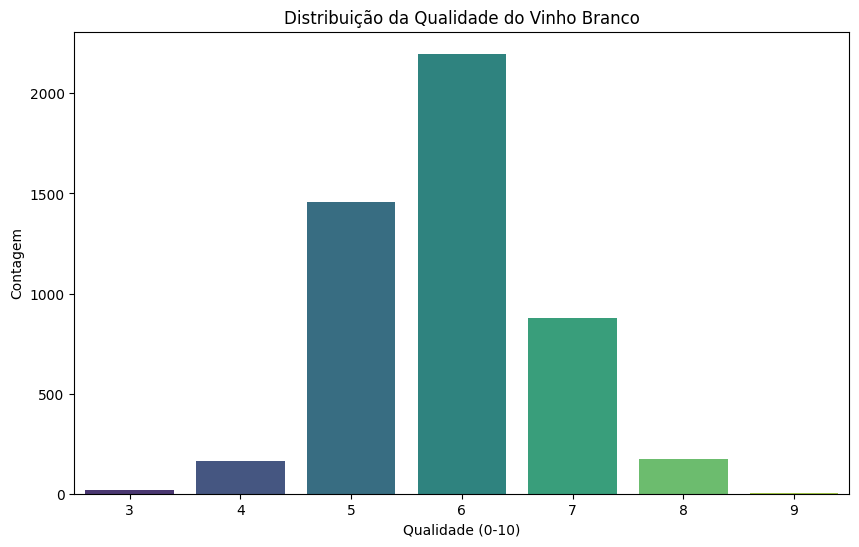

In [18]:
# Cria e salva um gráfico da distribuição da variável 'quality'.
plt.figure(figsize=(10, 6))
sns.countplot(data=df_white, x='quality', palette='viridis')
plt.title('Distribuição da Qualidade do Vinho Branco')
plt.xlabel('Qualidade (0-10)')
plt.ylabel('Contagem')
plt.savefig('quality_distribution.png')

2.2 Cria um heatmap (mapa de calor) para entender a correlação entre as variáveis


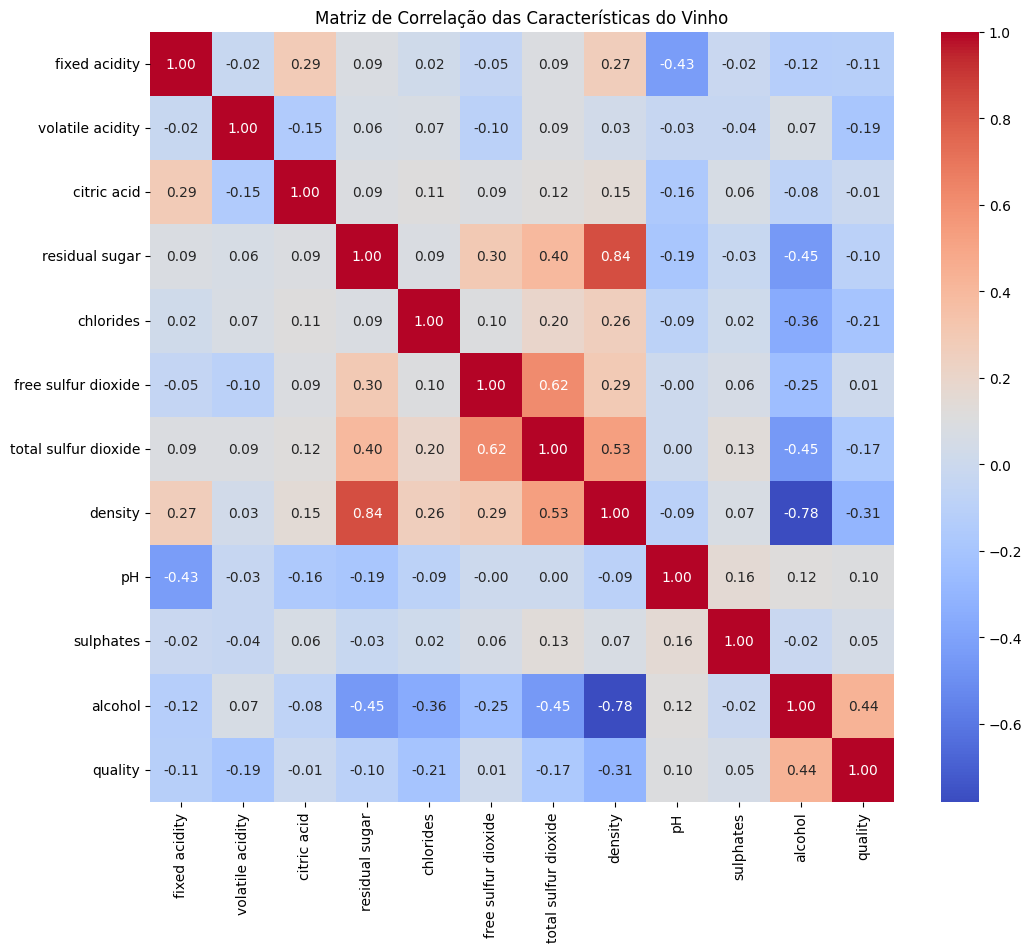

In [19]:
plt.figure(figsize=(12, 10))
correlation_matrix = df_white.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação das Características do Vinho')
plt.savefig('correlation_heatmap.png')


**Tá bom, mas o que isso implica?**

A imagem assim mostra uma matriz de correlação das características físico-químicas do vinho em relação à sua qualidade, além das correlações entre as próprias características. A matriz usa cores (de azul para negativo a vermelho para positivo) e valores numéricos que variam de -1 a 1:

1.00: correlação perfeita positiva (quando uma variável aumenta, a outra também).

-1.00: correlação perfeita negativa (quando uma variável aumenta, a outra diminui).

0: nenhuma correlação linear.


**Características mais relacionadas à qualidade do vinho:**

Álcool (0.44): A correlação mais forte com a qualidade. Ou seja, vinhos com maior teor alcoólico tendem a ser mais bem avaliados.

Density (-0.31): Densidade mais alta está associada a menor qualidade.




3.1 Criação dos modelos de regressão (comparação entre regressão linear e random forest regressor)

In [20]:
# Separa as variáveis independentes (features, X) da variável dependente (target, y).
X = df_white.drop('quality', axis=1) # Remove a coluna quality
y = df_white['quality']

# Divide os dados em conjuntos de treino e teste.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 20% dos dados para teste e valor arbitrário random

In [21]:
# --- Modelo 1: Regressão Linear ---
print("\n--- Treinando Modelo de Regressão Linear ---")
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

# Calcula as métricas de erro e performance.
mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("\nMétricas de Avaliação (Regressão Linear):")
print(f"  - MAE: {mae_linear:.4f}")
print(f"  - MSE: {mse_linear:.4f}")
print(f"  - R²: {r2_linear:.4f}")


--- Treinando Modelo de Regressão Linear ---

Métricas de Avaliação (Regressão Linear):
  - MAE: 0.5863
  - MSE: 0.5690
  - R²: 0.2653


In [22]:
# --- Modelo 2: Random Forest Regressor ---
print("\n--- Treinando Modelo Random Forest Regressor ---")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Calcula as métricas de erro e performance.
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\nMétricas de Avaliação (Random Forest):")
print(f"  - MAE: {mae_rf:.4f}")
print(f"  - MSE: {mse_rf:.4f}")
print(f"  - R²: {r2_rf:.4f}")



--- Treinando Modelo Random Forest Regressor ---

Métricas de Avaliação (Random Forest):
  - MAE: 0.4185
  - MSE: 0.3478
  - R²: 0.5510


3.2 Analisando resultados:

**Regressão linear:**

*   MAE: 0.5863 - Isso significa que, em média, o modelo erra por cerca de 0.59 pontos na previsão da qualidade (que normalmente varia de 3 a 9).
*   MSE: 0.5690 - Esse valor é coerente com o MAE. Novamente, não é ruim, mas indica que o modelo não está prevendo com muita precisão.
*   R²: 0.2653 - Um R² acima de 0.7 seria considerado bom nesse tipo de tarefa. Um R² abaixo de 0.3 geralmente sugere que o modelo é fraco ou limitado.

A regressão linear é um modelo simples, que pode não capturar relações não-lineares ou interações entre variáveis.


**Random Forest Regressor:**


*   MAE: 0.4185 - O modelo erra em média menos de meio ponto (0.42) na previsão da qualidade do vinho — isso já é muito mais preciso que o modelo anterior (que errava ~0.59).
*   MSE: 0.3478 - Caiu consideravelmente em relação à regressão linear (~0.5690). Isso mostra que o modelo está cometendo menos erros graves.
*   R²: 0.5510 - Agora o modelo explica mais de 55% da variância dos dados — mais que o dobro da explicação da regressão linear (26,5%).

Random Forest Regressor é melhor nesse caso por lidar melhor com relações não lineares, o que é o caso em uma análise de qualidade de vinho, que é uma análise "subjetiva".







4.1 Comparação entre os modelos



In [23]:
# Cria um DataFrame para comparar as métricas lado a lado.
results_df = pd.DataFrame({
    'Modelo': ['Regressão Linear', 'Random Forest'],
    'MAE': [mae_linear, mae_rf],
    'MSE': [mse_linear, mse_rf],
    'R²': [r2_linear, r2_rf]
})

print("\n--- Comparativo de Desempenho dos Modelos ---")
print(results_df.to_string(index=False))



--- Comparativo de Desempenho dos Modelos ---
          Modelo      MAE      MSE       R²
Regressão Linear 0.586267 0.569025 0.265275
   Random Forest 0.418520 0.347756 0.550978


4.2 Plotagem de gráfico de acordo com o modelo que melhor performou, o Random Forest

<ipython-input-24-2079738263>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances, y=feature_importances.index, palette='mako')


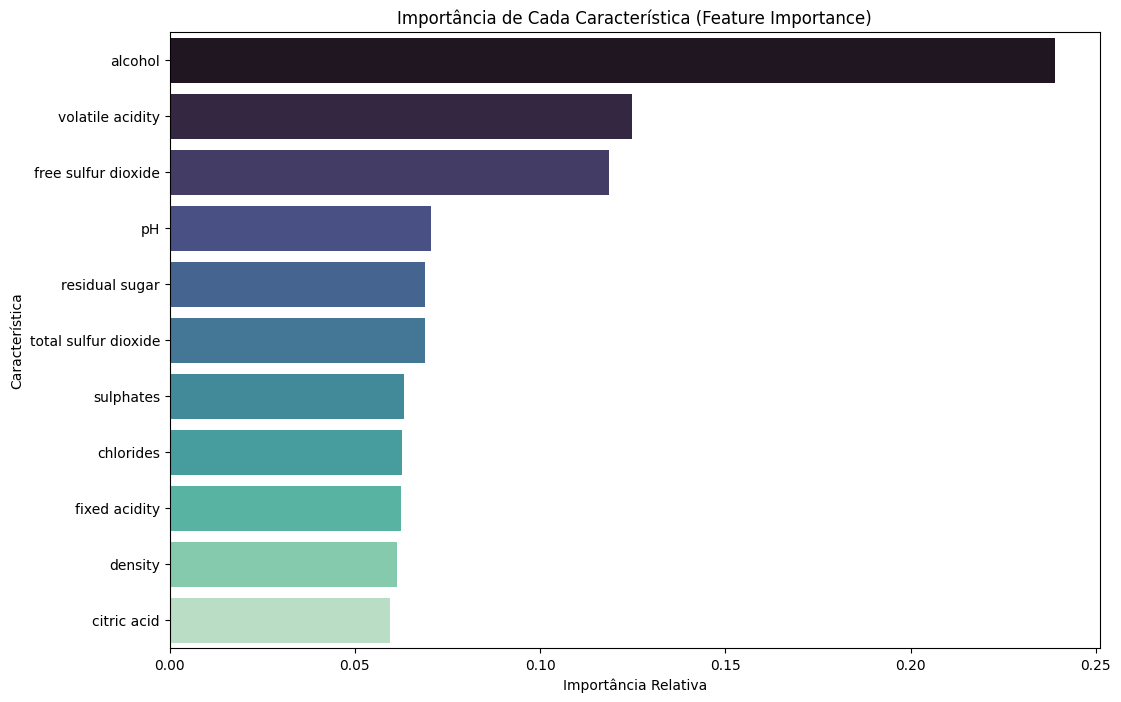

In [24]:
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importances, y=feature_importances.index, palette='mako')
plt.title('Importância de Cada Característica (Feature Importance)')
plt.xlabel('Importância Relativa')
plt.ylabel('Característica')
plt.savefig('feature_importance.png')

A plotagem dessas relações confirma o que foi analisado pelo heatmap na seção 2.2, mostrando um modelo de regressão condizente!